In [1]:
# LAB ASSIGNMENT - 3
# COURSE: AI IN HEALTHCARE
# PART B: TEXTUAL MEDICAL DATA
# DATASET: MTSamples Medical Transcriptions
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

In [2]:
# Download NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# 2. DATA ACQUISITION
# Load the MTSamples dataset
df = pd.read_csv("/content/archive (2).zip")
print("Dataset successfully loaded.")

Dataset successfully loaded.


In [4]:
# 3. DATA INSPECTION

print("\n FIRST FIVE RECORDS")
print(df.head())

print("\n DATASET SHAPE")
print(df.shape)

print("\n COLUMN NAMES")
print(df.columns.tolist())

print("\n DATASET INFORMATION")
df.info()

print("\n MISSING VALUES")
print(df.isnull().sum())


 FIRST FIVE RECORDS
   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr..

In [6]:
# 4. IDENTIFY THE TRANSCRIPTION COLUMN
if "transcription" in df.columns:
    text_column = "transcription"
else:
    raise ValueError(
        "The transcription column was not found. "
        "Check the column names using df.columns."
    )
print("Text column being used:", text_column)

Text column being used: transcription


In [8]:
# 5. BASIC DATA CLEANING
# Remove records where the medical transcription is missing
df = df.dropna(subset=[text_column])
# Convert transcription into string format
df[text_column] = df[text_column].astype(str)
print("Records after removing missing transcriptions:")
print(len(df))

Records after removing missing transcriptions:
4966


In [9]:
# 6. REMOVE DUPLICATE MEDICAL TRANSCRIPTIONS
duplicate_count = df[text_column].duplicated().sum()
print("\nNumber of duplicate transcriptions:")
print(duplicate_count)
df = df.drop_duplicates(
    subset=[text_column]
)
print("\nRecords after duplicate removal:")
print(len(df))


Number of duplicate transcriptions:
2609

Records after duplicate removal:
2357


In [10]:
# 7. PRESERVE ORIGINAL TEXT
# Keep a copy so that we can compare original and cleaned text.
df["original_text"] = df[text_column]

In [12]:
# 8. PHI REMOVAL
# PHI = Protected Health Information

# Medical text can potentially contain:
# - Names
# - Email addresses
# - Phone numbers
# - Dates
# - Medical record numbers
# - Patient IDs
#
# This function removes common identifiable patterns.

def remove_phi(text):
    text = str(text)
    # Remove email addresses
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " ",
        text
    )
    # Remove phone numbers
    text = re.sub(
        r"\b(?:\+?\d{1,3}[-.\s]?)?"
        r"(?:\(?\d{3}\)?[-.\s]?)?"
        r"\d{3}[-.\s]?\d{4}\b",
        " ",
        text
    )
    # Remove dates
    text = re.sub(
        r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
        " ",
        text
    )
    # Remove common patient identifiers
    text = re.sub(
        r"\b(?:patient\s*id|patient\s*no|"
        r"mrn|medical\s*record\s*(?:number|no)?)"
        r"\s*[:#-]?\s*\w+\b",
        " ",
        text,
        flags=re.IGNORECASE
    )
    # Remove SSN-like values
    text = re.sub(
        r"\b\d{3}-\d{2}-\d{4}\b",
        " ",
        text
    )
    return text
df["phi_removed_text"] = df["original_text"].apply(
    remove_phi
)
print("PHI removal completed.")

PHI removal completed.


In [14]:
# 9. TEXT CLEANING / NOISE REMOVAL
def clean_text(text):
    text = str(text)
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )
    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )
    # Keep alphabetic characters and spaces
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )
    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )
    # Remove leading/trailing spaces
    text = text.strip()
    return text
df["cleaned_text"] = df["phi_removed_text"].apply(
    clean_text
)
print("Text cleaning completed.")

Text cleaning completed.


In [15]:
# 10. DISPLAY ORIGINAL AND CLEANED TEXT
print("\n ORIGINAL TEXT ")
print(
    df["original_text"].iloc[0][:1000]
)
print("\n CLEANED TEXT ")
print(
    df["cleaned_text"].iloc[0][:1000]
)


 ORIGINAL TEXT 
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal sprays.  She does have asthma but doest not require daily medication for this and does not think it is flaring up.,MEDICATIONS: , Her only medication currently is Ortho Tri-Cyclen and the Allegra.,ALLERGIES: , She has no known medicine allergies.,OBJECTIVE:,Vitals:  Weight was 130 pounds and blood pressure 124/78.,HEENT:  Her throat was mildly erythematous without exudate.  Nasal mucosa was erythematous and swollen.  Only clear drainage was seen.  TMs were clear.,Neck:  Supple with

In [17]:
# 11. REMOVE EMPTY RECORDS
empty_records = (
    df["cleaned_text"]
    .str.strip()
    .eq("")
    .sum()
)
print("Empty records after cleaning:")
print(empty_records)
df = df[
    df["cleaned_text"].str.strip() != ""
]

Empty records after cleaning:
0


In [19]:
# 12. FEATURE ENGINEERING
# Create useful text-based features.
# Number of characters
df["character_count"] = df[
    "cleaned_text"
].apply(len)
# Number of words
df["word_count"] = df[
    "cleaned_text"
].apply(
    lambda text: len(text.split())
)
# Average word length
df["average_word_length"] = df.apply(
    lambda row:
    row["character_count"] / row["word_count"]
    if row["word_count"] > 0
    else 0,
    axis=1
)
print("TEXT FEATURES ")
print(
    df[
        [
            "character_count",
            "word_count",
            "average_word_length"
        ]
    ].describe()
)

TEXT FEATURES 
       character_count   word_count  average_word_length
count      2357.000000  2357.000000          2357.000000
mean       2835.044972   459.942300             6.260302
std        1891.375875   314.709527             0.479022
min           9.000000     1.000000             4.700000
25%        1467.000000   238.000000             5.993464
50%        2444.000000   393.000000             6.223377
75%        3732.000000   607.000000             6.470085
max       17617.000000  3027.000000            13.200000


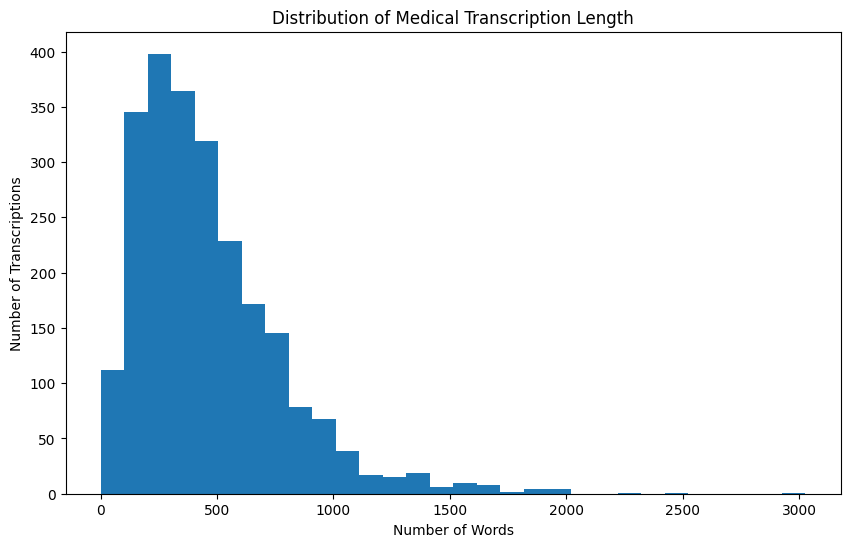

In [20]:
# 13. EDA - TEXT LENGTH
plt.figure(figsize=(10, 6))
plt.hist(
    df["word_count"],
    bins=30
)
plt.title(
    "Distribution of Medical Transcription Length"
)
plt.xlabel(
    "Number of Words"
)
plt.ylabel(
    "Number of Transcriptions"
)
plt.show()

MEDICAL SPECIALTY DISTRIBUTION
medical_specialty
Surgery                          976
Radiology                        248
General Medicine                 157
Urology                          156
SOAP / Chart / Progress Notes    144
Neurology                         67
Orthopedic                        56
Consult - History and Phy.        55
Pediatrics - Neonatal             52
Psychiatry / Psychology           51
Pain Management                   45
Office Notes                      41
Gastroenterology                  31
Hematology - Oncology             31
Cardiovascular / Pulmonary        26
Obstetrics / Gynecology           26
Nephrology                        20
Discharge Summary                 17
Sleep Medicine                    17
Emergency Room Reports            17
ENT - Otolaryngology              16
Ophthalmology                     15
Bariatrics                        10
Podiatry                          10
Physical Medicine - Rehab         10
Speech - Language         

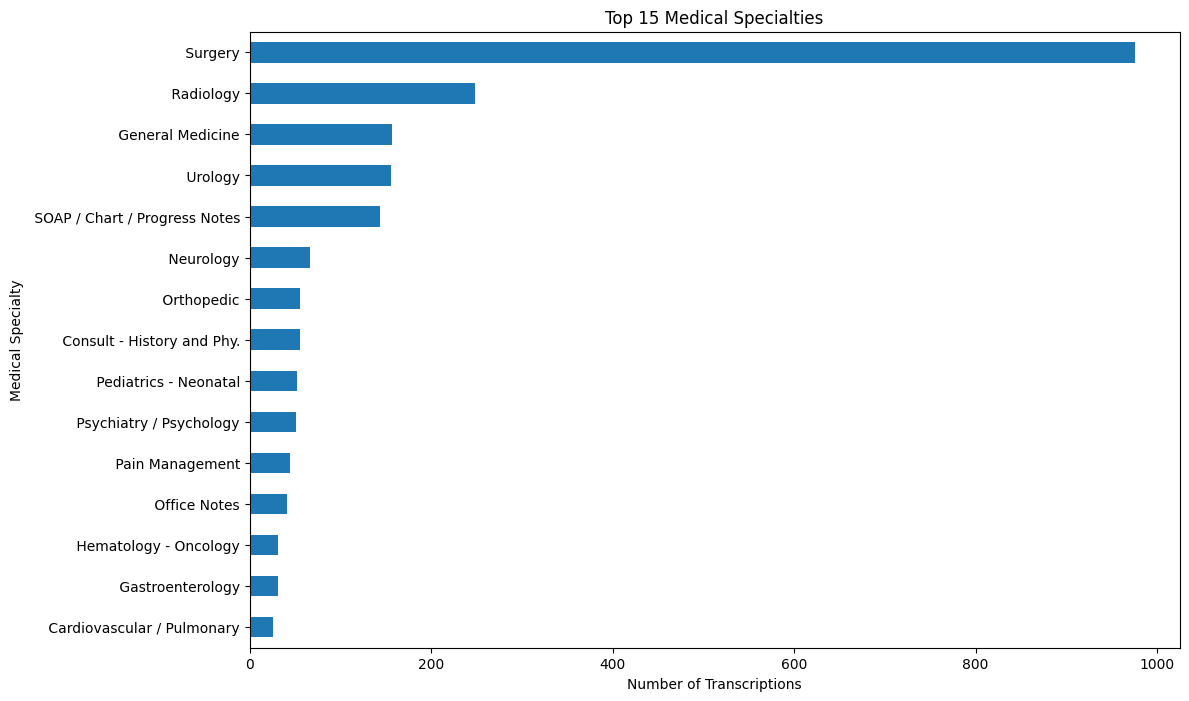

In [21]:
# 14. EDA - MEDICAL SPECIALTY
if "medical_specialty" in df.columns:
    specialty_counts = (
        df["medical_specialty"]
        .value_counts()
    )
    print("MEDICAL SPECIALTY DISTRIBUTION")
    print(specialty_counts)
    plt.figure(figsize=(12, 8))
    specialty_counts.head(15).sort_values().plot(
        kind="barh"
    )
    plt.title(
        "Top 15 Medical Specialties"
    )
    plt.xlabel(
        "Number of Transcriptions"
    )
    plt.ylabel(
        "Medical Specialty"
    )
    plt.show()

In [22]:
# 15. CHECK CLASS IMBALANCE
if "medical_specialty" in df.columns:
    class_distribution = (
        df["medical_specialty"]
        .value_counts(normalize=True)
        * 100
    )
    print(
        "CLASS DISTRIBUTION (%)"
    )
    print(
        class_distribution
    )
    print(
        "\nLargest class percentage:",
        class_distribution.iloc[0]
    )
    print(
        "Smallest class percentage:",
        class_distribution.iloc[-1]
    )

CLASS DISTRIBUTION (%)
medical_specialty
Surgery                          41.408570
Radiology                        10.521850
General Medicine                  6.661010
Urology                           6.618583
SOAP / Chart / Progress Notes     6.109461
Neurology                         2.842597
Orthopedic                        2.375902
Consult - History and Phy.        2.333475
Pediatrics - Neonatal             2.206194
Psychiatry / Psychology           2.163768
Pain Management                   1.909207
Office Notes                      1.739499
Gastroenterology                  1.315231
Hematology - Oncology             1.315231
Cardiovascular / Pulmonary        1.103097
Obstetrics / Gynecology           1.103097
Nephrology                        0.848536
Discharge Summary                 0.721256
Sleep Medicine                    0.721256
Emergency Room Reports            0.721256
ENT - Otolaryngology              0.678829
Ophthalmology                     0.636402
Bariatrics   

In [23]:
# 16. TOKENIZATION
df["tokens"] = df[
    "cleaned_text"
].apply(
    word_tokenize
)
print("\n========== TOKENIZATION EXAMPLE ==========")

print(
    df["tokens"].iloc[0][:50]
)


========== TOKENIZATION EXAMPLE ==========
['subjective', 'this', 'year', 'old', 'white', 'female', 'presents', 'with', 'complaint', 'of', 'allergies', 'she', 'used', 'to', 'have', 'allergies', 'when', 'she', 'lived', 'in', 'seattle', 'but', 'she', 'thinks', 'they', 'are', 'worse', 'here', 'in', 'the', 'past', 'she', 'has', 'tried', 'claritin', 'and', 'zyrtec', 'both', 'worked', 'for', 'short', 'time', 'but', 'then', 'seemed', 'to', 'lose', 'effectiveness', 'she', 'has']


In [24]:
# 17. STOPWORD REMOVAL
stop_words = set(
    stopwords.words("english")
)
def remove_stopwords(tokens):
    return [
        word
        for word in tokens
        if word not in stop_words
    ]
df["filtered_tokens"] = df[
    "tokens"
].apply(
    remove_stopwords
)
print("\nTOKENS BEFORE STOPWORD REMOVAL")
print(
    df["tokens"].iloc[0][:50]
)
print("\nTOKENS AFTER STOPWORD REMOVAL")
print(
    df["filtered_tokens"].iloc[0][:50]
)


TOKENS BEFORE STOPWORD REMOVAL
['subjective', 'this', 'year', 'old', 'white', 'female', 'presents', 'with', 'complaint', 'of', 'allergies', 'she', 'used', 'to', 'have', 'allergies', 'when', 'she', 'lived', 'in', 'seattle', 'but', 'she', 'thinks', 'they', 'are', 'worse', 'here', 'in', 'the', 'past', 'she', 'has', 'tried', 'claritin', 'and', 'zyrtec', 'both', 'worked', 'for', 'short', 'time', 'but', 'then', 'seemed', 'to', 'lose', 'effectiveness', 'she', 'has']

TOKENS AFTER STOPWORD REMOVAL
['subjective', 'year', 'old', 'white', 'female', 'presents', 'complaint', 'allergies', 'used', 'allergies', 'lived', 'seattle', 'thinks', 'worse', 'past', 'tried', 'claritin', 'zyrtec', 'worked', 'short', 'time', 'seemed', 'lose', 'effectiveness', 'used', 'allegra', 'also', 'used', 'last', 'summer', 'began', 'using', 'two', 'weeks', 'ago', 'appear', 'working', 'well', 'used', 'counter', 'sprays', 'prescription', 'nasal', 'sprays', 'asthma', 'doest', 'require', 'daily', 'medication', 'think']


In [25]:
# 18. RECONSTRUCT PROCESSED TEXT
df["processed_text"] = df[
    "filtered_tokens"
].apply(
    lambda tokens: " ".join(tokens)
)
print("PROCESSED TEXT")
print(
    df["processed_text"].iloc[0][:1000]
)

PROCESSED TEXT
subjective year old white female presents complaint allergies used allergies lived seattle thinks worse past tried claritin zyrtec worked short time seemed lose effectiveness used allegra also used last summer began using two weeks ago appear working well used counter sprays prescription nasal sprays asthma doest require daily medication think flaring medications medication currently ortho tri cyclen allegra allergies known medicine allergies objective vitals weight pounds blood pressure heent throat mildly erythematous without exudate nasal mucosa erythematous swollen clear drainage seen tms clear neck supple without adenopathy lungs clear assessment allergic rhinitis plan try zyrtec instead allegra another option use loratadine think prescription coverage might cheaper samples nasonex two sprays nostril given three weeks prescription written well


In [27]:
# 19. WORD FREQUENCY ANALYSIS
all_words = []
for tokens in df["filtered_tokens"]:
    all_words.extend(tokens)
word_frequency = Counter(
    all_words
)
print(
    "TOP 20 MOST FREQUENT WORDS"
)
for word, frequency in (
    word_frequency.most_common(20)
):
    print(
        word,
        ":",
        frequency
    )

TOP 20 MOST FREQUENT WORDS
patient : 11269
right : 5469
left : 5338
history : 4351
procedure : 3605
normal : 3430
placed : 3302
well : 3094
pain : 2683
mg : 2122
also : 2029
time : 1992
x : 1989
noted : 1978
using : 1923
blood : 1861
performed : 1854
skin : 1777
anesthesia : 1769
without : 1691


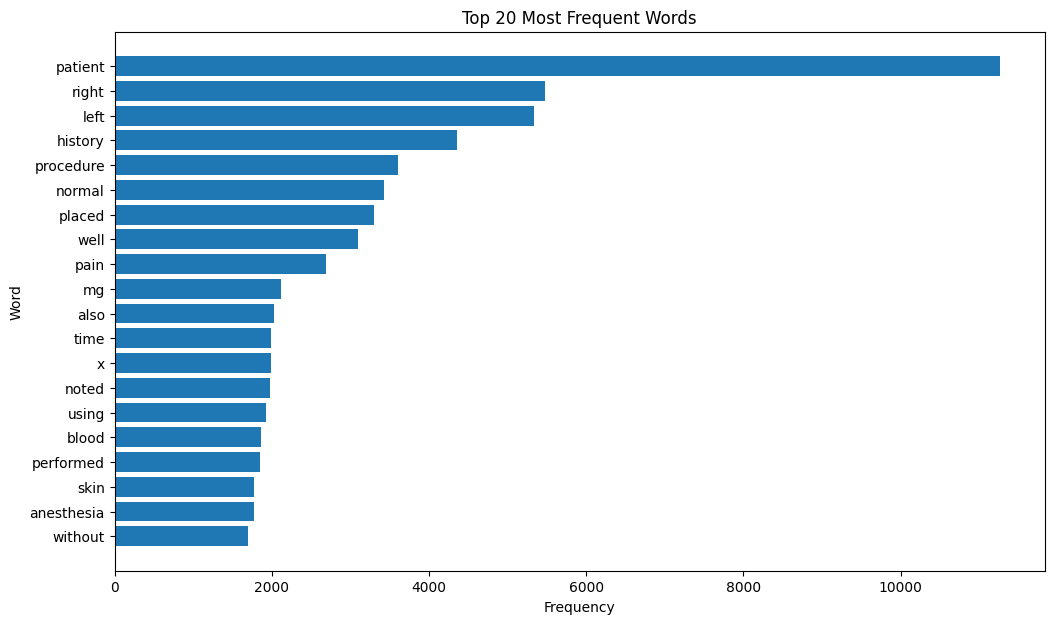

In [28]:
# 20. WORD FREQUENCY VISUALIZATION
common_words = (
    word_frequency
    .most_common(20)
)
words = [
    item[0]
    for item in common_words
]
frequencies = [
    item[1]
    for item in common_words
]
plt.figure(figsize=(12, 7))
plt.barh(
    words[::-1],
    frequencies[::-1]
)
plt.title(
    "Top 20 Most Frequent Words"
)
plt.xlabel(
    "Frequency"
)
plt.ylabel(
    "Word"
)
plt.show()

In [29]:
# 21. FEATURE EXTRACTION USING TF-IDF
tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.95
)
X_tfidf = tfidf.fit_transform(
    df["processed_text"]
)
print(
    "TF-IDF"
)
print(
    "TF-IDF matrix shape:",
    X_tfidf.shape
)

TF-IDF
TF-IDF matrix shape: (2357, 1000)


In [30]:
# 22. FEATURE SELECTION / VOCABULARY INSPECTION
feature_names = (
    tfidf.get_feature_names_out()
)
print(
    "\nNumber of selected TF-IDF features:"
)
print(
    len(feature_names)
)
print(
    "\nFirst 50 selected features:"
)
print(
    feature_names[:50]
)


Number of selected TF-IDF features:
1000

First 50 selected features:
['abc' 'abcd' 'abdomen' 'abdominal' 'able' 'abnormal' 'abnormalities'
 'abscess' 'abuse' 'achieved' 'across' 'active' 'activities' 'activity'
 'acute' 'addition' 'additional' 'adenopathy' 'adequate' 'adhesions'
 'administered' 'admission' 'admitted' 'advanced' 'age' 'ago' 'air'
 'alcohol' 'alert' 'allergies' 'along' 'also' 'alternatives' 'although'
 'amount' 'anastomosis' 'anemia' 'anesthesia' 'anesthetic' 'ankle'
 'another' 'anterior' 'anteriorly' 'antibiotic' 'antibiotics' 'anxiety'
 'aorta' 'aortic' 'apparent' 'apparently']


In [31]:
# 23. CREATE TF-IDF DATAFRAME
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=feature_names
)
print(
    "TF-IDF DATA"
)
print(
    tfidf_df.head()
)

TF-IDF DATA
        abc  abcd   abdomen  abdominal      able  abnormal  abnormalities  \
0  0.000000   0.0  0.000000        0.0  0.000000  0.000000       0.000000   
1  0.000000   0.0  0.000000        0.0  0.000000  0.000000       0.000000   
2  0.052393   0.0  0.030144        0.0  0.040062  0.000000       0.000000   
3  0.000000   0.0  0.000000        0.0  0.000000  0.000000       0.000000   
4  0.000000   0.0  0.000000        0.0  0.000000  0.061505       0.064207   

   abscess  abuse  achieved  ...   without  work    workup     worse  \
0      0.0    0.0       0.0  ...  0.134283   0.0  0.000000  0.137168   
1      0.0    0.0       0.0  ...  0.000000   0.0  0.000000  0.000000   
2      0.0    0.0       0.0  ...  0.000000   0.0  0.054909  0.000000   
3      0.0    0.0       0.0  ...  0.000000   0.0  0.000000  0.000000   
4      0.0    0.0       0.0  ...  0.000000   0.0  0.000000  0.000000   

      would  wound  wrist       xyz      year     years  
0  0.000000    0.0    0.0  0.00000

In [32]:
# 24. CREATE INTEGER VOCABULARY
vocabulary = {}
word_id = 1
for tokens in df[
    "filtered_tokens"
]:
    for word in tokens:
        if word not in vocabulary:
            vocabulary[word] = word_id
            word_id += 1
print(
    "VOCABULARY"
)
print(
    "Vocabulary size:",
    len(vocabulary)
)

VOCABULARY
Vocabulary size: 20848


In [33]:
# 25. CONVERT TEXT INTO TOKEN SEQUENCES
def convert_to_sequence(tokens):
    return [
        vocabulary[word]
        for word in tokens
        if word in vocabulary
    ]
df["token_sequence"] = df[
    "filtered_tokens"
].apply(
    convert_to_sequence
)
print(
    "TOKEN SEQUENCE EXAMPLE"
)
print(
    df["token_sequence"].iloc[0][:50]
)

TOKEN SEQUENCE EXAMPLE
[1, 2, 3, 4, 5, 6, 7, 8, 9, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 9, 24, 25, 9, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 9, 36, 37, 38, 39, 37, 40, 41, 42, 43, 44, 45]


In [34]:
# 26. ANALYZE TOKEN SEQUENCE LENGTH
df["sequence_length"] = df[
    "token_sequence"
].apply(len)
print(
    "SEQUENCE LENGTH"
)
print(
    df["sequence_length"].describe()
)

SEQUENCE LENGTH
count    2357.000000
mean      271.291896
std       176.787357
min         1.000000
25%       143.000000
50%       237.000000
75%       358.000000
max      1674.000000
Name: sequence_length, dtype: float64


In [36]:
# 27. PADDING / TRUNCATION
MAX_LENGTH = 200
def pad_sequence(
    sequence,
    max_length=MAX_LENGTH
):
    # Truncate sequences that are too long
    if len(sequence) > max_length:
        return sequence[:max_length]
    # Pad shorter sequences with zero
    return sequence + [0] * (
        max_length - len(sequence)
    )
df["padded_sequence"] = df[
    "token_sequence"
].apply(
    pad_sequence
)
print(
    "PADDED SEQUENCE"
)
print(
    df["padded_sequence"].iloc[0]
)
print(
    "\nPadded sequence length:",
    len(df["padded_sequence"].iloc[0])
)

PADDED SEQUENCE
[1, 2, 3, 4, 5, 6, 7, 8, 9, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 9, 24, 25, 9, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 9, 36, 37, 38, 39, 37, 40, 41, 42, 43, 44, 45, 46, 47, 44, 48, 49, 50, 51, 24, 8, 52, 53, 8, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 39, 66, 63, 67, 68, 69, 70, 71, 68, 72, 73, 64, 74, 75, 68, 76, 77, 78, 79, 80, 17, 81, 24, 82, 83, 84, 85, 45, 38, 86, 87, 88, 89, 90, 30, 37, 91, 92, 93, 31, 38, 94, 35, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Padded sequence length: 200


In [37]:
# 28. CONVERT TO NUMPY ARRAY
X_sequences = np.array(
    df["padded_sequence"].tolist()
)
print(
    "MODEL-READY DATA"
)
print(
    "Token sequence shape:",
    X_sequences.shape
)

MODEL-READY DATA
Token sequence shape: (2357, 200)


In [38]:
# 29. TRAIN-TEST SPLIT
X_train, X_test = train_test_split(
    X_sequences,
    test_size=0.20,
    random_state=42
)
print(
    "\nTraining data shape:",
    X_train.shape
)
print(
    "Testing data shape:",
    X_test.shape
)


Training data shape: (1885, 200)
Testing data shape: (472, 200)


In [39]:
# 30. FINAL DATASET INSPECTION
print(
    "FINAL DATASET"
)
print(
    "Final number of records:",
    len(df)
)
print(
    "\nFinal columns:"
)
print(
    df.columns.tolist()
)

FINAL DATASET
Final number of records: 2357

Final columns:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'original_text', 'phi_removed_text', 'cleaned_text', 'character_count', 'word_count', 'average_word_length', 'tokens', 'filtered_tokens', 'processed_text', 'token_sequence', 'sequence_length', 'padded_sequence']
